<a href="https://colab.research.google.com/github/gapalfaro-cmyk/gapalfaro-cmyk-Proyecto-de-fin-de-modulo-7.2---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/DiplomadoIACD_Survival_sesion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión sobre el uso de redes neuronales en análisis de supervivencia

En las últimas sesiones hemos estudiado el análisis de supervivencia, particularmente el *modelo de riesgo proporcional de Cox*. Hemos visto la necesidad de usar optimizadores estocásticos como SGD y sus variantes para ajustar este modelo, y también discutimos la forma de manejar los conjuntos de riesgo a la hora de implementar SGD en el análisis de supervivencia. En este notebook veremos cómo extender estos modelos con el uso de redes neuronales, en particular estudiaremos la paquetería `PyCox`. Quedará como trabajo de clase-tarea implementar los métodos vistos con una base de datos real como `SUPPORT`, `METABRIC`, `Rot. & GBSG` o `FLCHAIN`.

In [ ]:
!pip -q install pycox

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [ ]:
# Generar datos simulados (tiempos de ocurrencia de acuerdo a una distribución Weibull)

def true_log_risk_nonlinear(x, lambda_max=5.0, r=0.5):
    # x: array shape (N, d)
    return np.log(lambda_max) * np.exp(
        -(x[:, 0]**2 + x[:, 1]**2) / (2 * r**2)
    )

def simulate_event_times_nonlinear(x, k=1.5, lambda0=0.2, lambda_max=5.0, r=0.5, seed=None):
    rng = np.random.default_rng(seed)

    h = true_log_risk_nonlinear(x, lambda_max=lambda_max, r=r)
    lam = lambda0 * np.exp(h / k)

    u = rng.uniform(size=x.shape[0])
    e = -np.log(u)  # Exp(1)

    t = e**(1 / k) / lam

    return t, h, lam

# Applying censoring

def find_trial_end_time(t_event, target_event_rate=0.9):
    """
    Choose T0 so that approximately target_event_rate proportion
    of individuals have an observed event.

    Z_i = min(T_i, T0)
    status_i = 1{T_i <= T0}
    """
    return np.quantile(t_event, target_event_rate)


def apply_censoring(t_event, trial_end_time):
    """
    Apply administrative right censoring at fixed trial end time T0.
    """
    time_observed = np.minimum(t_event, trial_end_time)
    status = (t_event <= trial_end_time).astype(np.float32)

    # Same censoring time for every individual
    censoring = np.full_like(t_event, trial_end_time, dtype=np.float32)

    return time_observed, status, censoring

# Generation

def generate_split_nonlinear(n, d=10, lambda0=0.2, lambda_max=5.0, r=0.5,
                   trial_end_time=None, seed=1234):
    rng = np.random.default_rng(seed)

    x = rng.uniform(-1.0, 1.0, size=(n, d)).astype(np.float32)

    t_event, h_true, rate = simulate_event_times_nonlinear(
        x,
        lambda0=lambda0,
        lambda_max=lambda_max,
        r=r,
        seed=seed + 1
    )

    time_obs, status, censoring = apply_censoring(
        t_event,
        trial_end_time
    )

    return {
        "x": x,
        "time": time_obs.astype(np.float32),
        "status": status.astype(np.float32),
        "h_true": h_true.astype(np.float32),
        "t_event": t_event.astype(np.float32),
        "censoring": censoring.astype(np.float32),
        "rate": rate.astype(np.float32),
    }

In [ ]:
N_train, N_val, N_test = 4000, 1000, 1000
d = 10
target_event_rate = 0.9
lambda0=0.02
lambda_max = 5.0
r = 0.5
rng_tmp = np.random.default_rng(2024)
x_tmp = rng_tmp.uniform(-1.0, 1.0, size=(N_train, d)).astype(np.float32)

In [ ]:
t_tmp, h_tmp, _ = simulate_event_times_nonlinear(
    x_tmp,
    lambda0=lambda0,
    seed=2025
)

trial_end_time = find_trial_end_time(
    t_tmp,
    target_event_rate=target_event_rate
)

print("Trial end time T0:", trial_end_time)

Trial end time T0: 62.36735907823209


In [ ]:
train = generate_split_nonlinear(
    N_train,
    d=d,
    lambda0=lambda0,
    lambda_max=lambda_max,
    r=r,
    trial_end_time=trial_end_time,
    seed=10
)

val = generate_split_nonlinear(
    N_val,
    d=d,
    lambda0=lambda0,
    lambda_max=lambda_max,
    r=r,
    trial_end_time=trial_end_time,
    seed=20
)

test = generate_split_nonlinear(
    N_test,
    d=d,
    lambda0=lambda0,
    lambda_max=lambda_max,
    r=r,
    trial_end_time=trial_end_time,
    seed=30
)

print("Event rate train:", train["status"].mean())
print("Event rate val:  ", val["status"].mean())
print("Event rate test: ", test["status"].mean())

Event rate train: 0.894
Event rate val:   0.89
Event rate test:  0.884


In [ ]:
# Modelo DeepSurv

class DeepSurvRisk(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dims=(32, 32, 32),
        dropout=0.0
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:

            layers.append(
                nn.Linear(prev_dim, h)
            )

            layers.append(
                nn.Tanh()
            )

            if dropout > 0:
                layers.append(
                    nn.Dropout(dropout)
                )

            prev_dim = h

        # Un score de riesgo por individuo
        layers.append(
            nn.Linear(prev_dim, 1)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
# Número de covariables
input_dim = train["x"].shape[1]


# Crear la red
net = DeepSurvRisk(
    input_dim=input_dim,
    hidden_dims=(32, 32, 32),
    dropout=0.0
)


# Crear el modelo Cox de PyCox
model = CoxPH(
    net,
    optimizer=torch.optim.Adam
)


# Learning rate
model.optimizer.set_lr(1e-3)

In [ ]:
x_train = train["x"].astype("float32")
time_train = train["time"].astype("float32")
status_train = train["status"].astype("float32")

x_val = val["x"].astype("float32")
time_val = val["time"].astype("float32")
status_val = val["status"].astype("float32")

In [ ]:
log = model.fit(
    input=x_train,
    target=(time_train, status_train),
    batch_size=64,
    epochs=100,
    val_data=(
        x_val,
        (time_val, status_val)
    ),
    verbose=True
)

0:	[0s / 0s],		train_loss: 3.4304,	val_loss: 6.1831
1:	[0s / 0s],		train_loss: 3.4285,	val_loss: 6.1829
2:	[0s / 0s],		train_loss: 3.4276,	val_loss: 6.1834
3:	[0s / 0s],		train_loss: 3.4281,	val_loss: 6.1830
4:	[0s / 0s],		train_loss: 3.4274,	val_loss: 6.1823
5:	[0s / 1s],		train_loss: 3.4272,	val_loss: 6.1835
6:	[0s / 1s],		train_loss: 3.4255,	val_loss: 6.1817
7:	[0s / 1s],		train_loss: 3.4250,	val_loss: 6.1815
8:	[0s / 1s],		train_loss: 3.4213,	val_loss: 6.1771
9:	[0s / 1s],		train_loss: 3.4189,	val_loss: 6.1719
10:	[0s / 2s],		train_loss: 3.4123,	val_loss: 6.1629
11:	[0s / 2s],		train_loss: 3.3956,	val_loss: 6.1455
12:	[0s / 2s],		train_loss: 3.3827,	val_loss: 6.1206
13:	[0s / 2s],		train_loss: 3.3701,	val_loss: 6.1211
14:	[0s / 2s],		train_loss: 3.3655,	val_loss: 6.1040
15:	[0s / 3s],		train_loss: 3.3622,	val_loss: 6.1058
16:	[0s / 3s],		train_loss: 3.3565,	val_loss: 6.1034
17:	[0s / 3s],		train_loss: 3.3598,	val_loss: 6.1008
18:	[0s / 3s],		train_loss: 3.3540,	val_loss: 6.1041
19:

<Axes: >

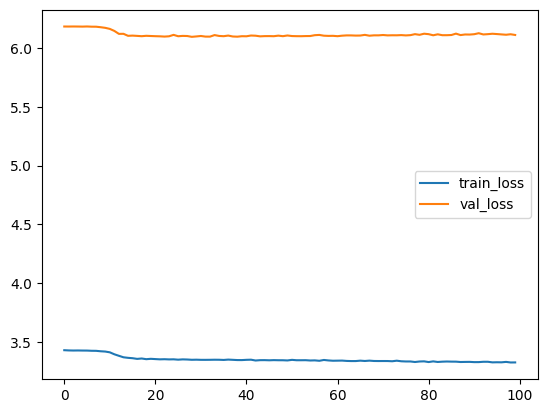

In [ ]:
log.plot()

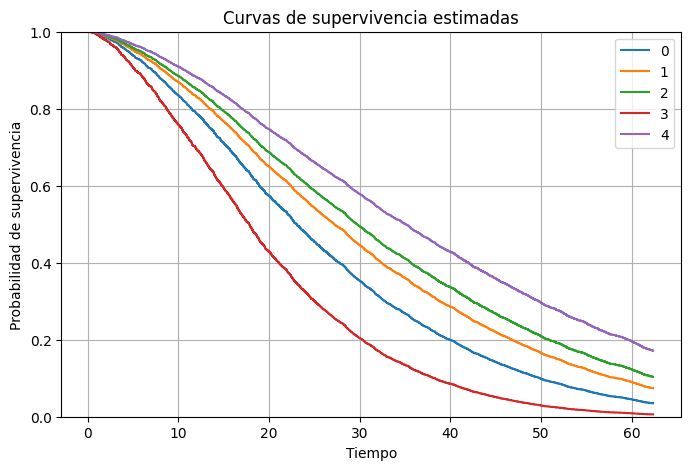

In [ ]:
# 1. Estimación de Breslow con entrenamiento
model.compute_baseline_hazards()

# 2. Curvas de supervivencia para test
x_test = test["x"].astype("float32")
time_test = test["time"]
status_test = test["status"]

surv_test = model.predict_surv_df(x_test)

# 3. Graficar cinco individuos
surv_test.iloc[:, :5].plot(
    figsize=(8, 5),
    drawstyle="steps-post"
)

plt.xlabel("Tiempo")
plt.ylabel("Probabilidad de supervivencia")
plt.title("Curvas de supervivencia estimadas")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [ ]:
ev = EvalSurv(
    surv_test,
    time_test,
    status_test
)

c_index = ev.concordance_td()

print("C-index PyCox:", c_index)

C-index PyCox: 0.5971968021427267


## Trabajo de clase

Seleccione **una** de las siguientes bases de datos:

- SUPPORT
- METABRIC
- Rotterdam & GBSG
- FLCHAIN

### Instrucciones

1. Identifique las covariables, el tiempo observado y el indicador de evento.

2. Divida la base de datos en conjuntos de:
   - Entrenamiento
   - Validación
   - Prueba

3. Ajuste los siguientes modelos utilizando la misma partición de los datos:
   - Modelo de riesgos proporcionales de Cox tradicional.
   - Modelo DeepSurv utilizando PyCox.

4. Evalúe ambos modelos sobre el conjunto de prueba mediante el C-index.

5. Para el modelo DeepSurv, presente:
   - Gráfica de la pérdida de entrenamiento y validación.
   - Curvas de supervivencia estimadas para al menos tres individuos.

6. Presente una tabla comparativa con el C-index de ambos modelos.

7. Escriba una conclusión breve indicando:
   - Qué modelo obtuvo mejor desempeño.
   - Si DeepSurv produjo una mejora relevante frente al modelo de Cox.
   - Qué posibles razones explican los resultados obtenidos.

### Entrega

Entregue el notebook ejecutado, incluyendo el código, las gráficas, la tabla comparativa y la interpretación de los resultados.
